In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

sns.set(style='whitegrid')


In [45]:
data = pd.read_excel("C:/Users/Chet/Documents/HR Data.xlsx")

In [46]:
data

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus
0,31,No,Non-Travel,158,Software,7,3,Medical,1,1,3,Male,42,2,3,Developer,1,Married
1,38,No,Travel_Rarely,985,Human Resources,33,5,Life Sciences,1,2,1,Female,66,2,4,Healthcare Representative,3,Single
2,59,Yes,Non-Travel,1273,Sales,5,2,Technical Degree,1,3,4,Female,96,1,3,Manufacturing Director,2,Married
3,52,Yes,Travel_Rarely,480,Support,2,5,Marketing,1,4,4,Female,71,2,4,Human Resources,1,Married
4,32,No,Non-Travel,543,Human Resources,7,5,Human Resources,1,5,2,Male,122,3,3,Manager,2,Divorced
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,55,Yes,Travel_Rarely,1226,Research & Development,28,1,Technical Degree,1,49996,1,Female,92,4,5,Research Director,2,Divorced
49996,39,Yes,Travel_Rarely,1201,Human Resources,33,4,Medical,1,49997,4,Female,112,2,2,Human Resources,3,Single
49997,44,No,Travel_Rarely,232,Software,47,4,Technical Degree,1,49998,4,Female,62,1,5,Manager,3,Single
49998,49,No,Travel_Rarely,1390,Human Resources,40,4,Other,1,49999,3,Male,177,1,5,Healthcare Representative,4,Single


In [47]:
data.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.0,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,38.971480,798.677560,25.539780,3.004600,1.0,25000.500000,2.498360,115.432940,2.502620,2.994640,2.487380
std,12.420834,405.080217,14.339956,1.414249,0.0,14433.901067,1.119671,49.424867,1.120544,1.415998,1.116309
min,18.000000,100.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000
25%,28.000000,445.000000,13.000000,2.000000,1.0,12500.750000,1.000000,73.000000,1.000000,2.000000,1.000000
50%,39.000000,798.000000,25.000000,3.000000,1.0,25000.500000,2.000000,116.000000,3.000000,3.000000,2.000000
75%,50.000000,1151.000000,38.000000,4.000000,1.0,37500.250000,4.000000,158.000000,4.000000,4.000000,3.000000
max,60.000000,1500.000000,50.000000,5.000000,1.0,50000.000000,4.000000,200.000000,4.000000,5.000000,4.000000


## Data Cleaning and Missing Data Analysis

In [49]:
data.columns = data.columns.str.strip().str.lower().str.replace(' ', '_')
print(data.head())
print(data.info())
print("Missing values:\n", data.isnull().sum())

   age attrition businesstravel  dailyrate       department  distancefromhome  \
0   31        No     Non-Travel        158         Software                 7   
1   38        No  Travel_Rarely        985  Human Resources                33   
2   59       Yes     Non-Travel       1273            Sales                 5   
3   52       Yes  Travel_Rarely        480          Support                 2   
4   32        No     Non-Travel        543  Human Resources                 7   

   education    educationfield  employeecount  employeenumber  \
0          3           Medical              1               1   
1          5     Life Sciences              1               2   
2          2  Technical Degree              1               3   
3          5         Marketing              1               4   
4          5   Human Resources              1               5   

   environmentsatisfaction  gender  hourlyrate  jobinvolvement  joblevel  \
0                        3    Male          42

## Employee Attrition Distribution Visualization

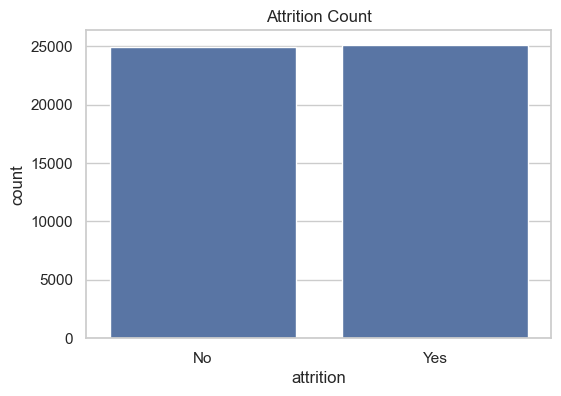

In [55]:
# Attrition count
plt.figure(figsize=(6, 4))
sns.countplot(x='attrition', data=data)
plt.title('Attrition Count')
plt.show()

## Employee Attrition Analysis by Department¶

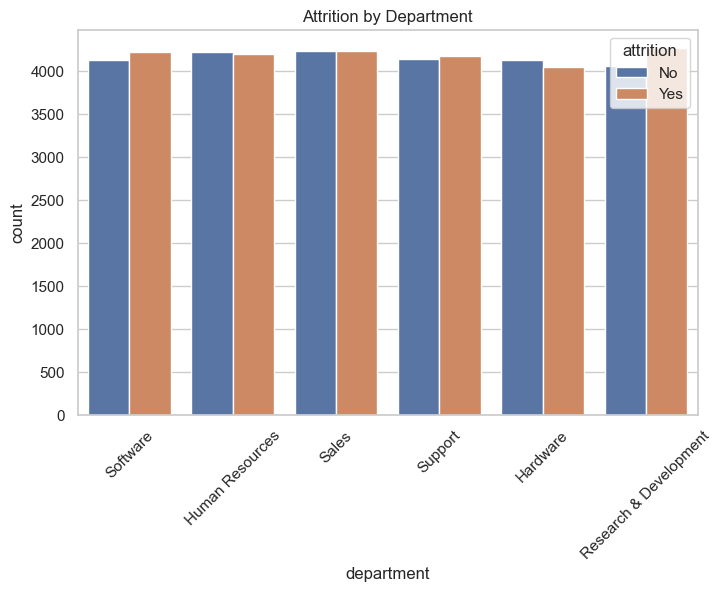

In [57]:
# Attrition by Department
plt.figure(figsize=(8, 5))
sns.countplot(x='department', hue='attrition', data=data)
plt.title('Attrition by Department')
plt.xticks(rotation=45)
plt.show()


## Job Satisfaction vs Employee Attrition Analysis

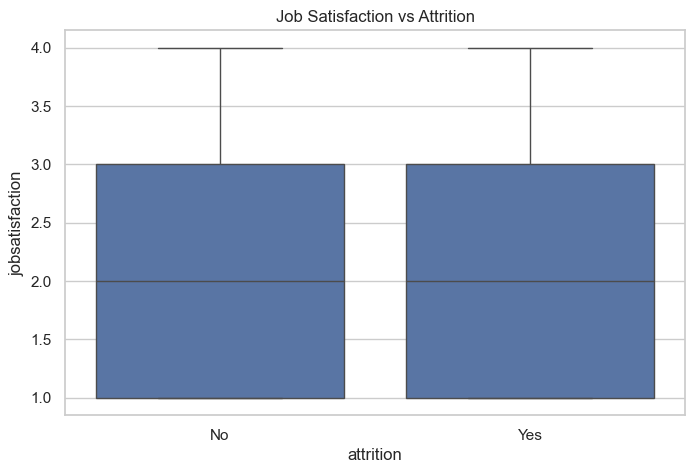

In [60]:
# Job Satisfaction by Attrition
plt.figure(figsize=(8, 5))
sns.boxplot(x='attrition', y='jobsatisfaction', data=data)
plt.title('Job Satisfaction vs Attrition')
plt.show()

## Correlation Matrix Visualization

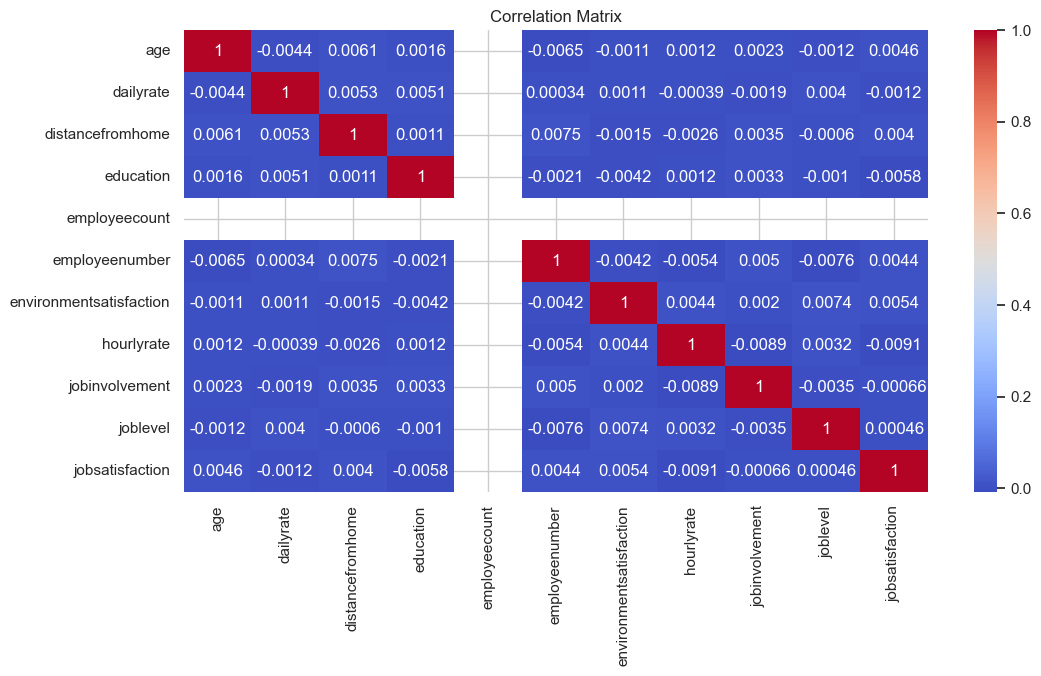

In [62]:
plt.figure(figsize=(12, 6))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()


## Data Preprocessing – Encoding, Splitting, and Scaling Features



In [64]:
# Encode categorical variables
categorical_cols = data.select_dtypes(include=['object']).columns
print("Categorical columns:", list(categorical_cols))

le = LabelEncoder()
for col in categorical_cols:
    data[col] = le.fit_transform(data[col])
    print(f"Encoded '{col}' → Unique classes: {le.classes_}")

# Features and target
X = data.drop('attrition', axis=1)
y = data['attrition']

print("\nFirst 5 rows of features (X):")
print(X.head())

print("\nFirst 5 values of target (y):")
print(y.head())

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convert scaled features back to DataFrame for easier viewing
X_train_df = pd.DataFrame(X_train, columns=X.columns)
X_test_df = pd.DataFrame(X_test, columns=X.columns)

print("\nSample of scaled training features:")
print(X_train_df.head())

print("\nSample of scaled test features:")
print(X_test_df.head())


Categorical columns: ['attrition', 'businesstravel', 'department', 'educationfield', 'gender', 'jobrole', 'maritalstatus']
Encoded 'attrition' → Unique classes: ['No' 'Yes']
Encoded 'businesstravel' → Unique classes: ['Non-Travel' 'Travel_Frequently' 'Travel_Rarely']
Encoded 'department' → Unique classes: ['Hardware' 'Human Resources' 'Research & Development' 'Sales' 'Software'
 'Support']
Encoded 'educationfield' → Unique classes: ['Human Resources' 'Life Sciences' 'Marketing' 'Medical' 'Other'
 'Technical Degree']
Encoded 'gender' → Unique classes: ['Female' 'Male']
Encoded 'jobrole' → Unique classes: ['Developer' 'Healthcare Representative' 'Human Resources'
 'Laboratory Technician' 'Manager' 'Manufacturing Director'
 'Research Director' 'Research Scientist' 'Sales Executive'
 'Sales Representative']
Encoded 'maritalstatus' → Unique classes: ['Divorced' 'Married' 'Single']

First 5 rows of features (X):
   age  businesstravel  dailyrate  department  distancefromhome  education  \
0 

## Machine Learning Model Training and Evaluation

In [67]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.49      0.52      0.51      4931
           1       0.50      0.48      0.49      5069

    accuracy                           0.50     10000
   macro avg       0.50      0.50      0.50     10000
weighted avg       0.50      0.50      0.50     10000

Confusion Matrix:
 [[2564 2367]
 [2658 2411]]


## Feature Importance Visualization in Machine Learning

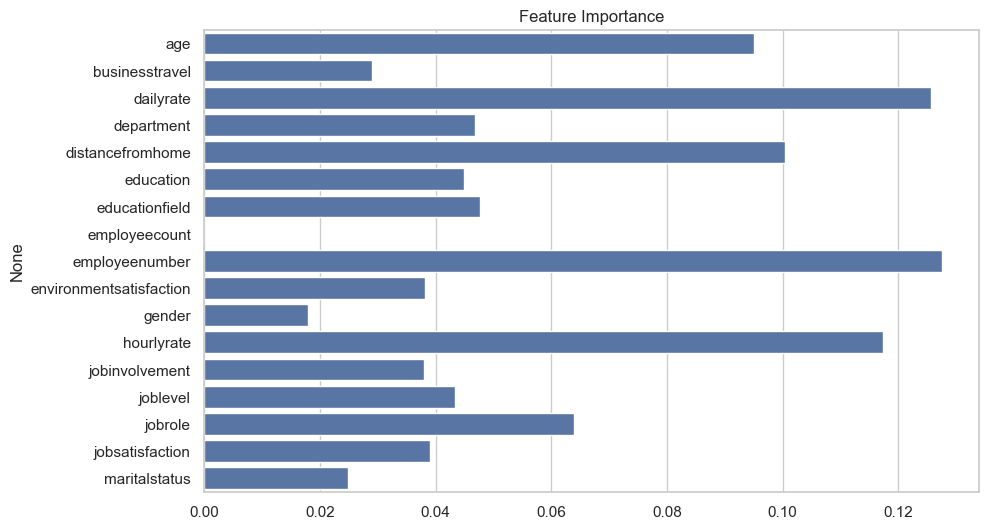

In [70]:
importances = model.feature_importances_
features = X.columns

plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=features)
plt.title('Feature Importance')
plt.show()
